<a href="https://colab.research.google.com/github/SilviaRuth/AI-powered-study/blob/main/Copy_of_CITS4012_63.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2025 CITS4012 Project

# Readme
We used some Object Oriented Programming and chose to put it in the main code sections rather than at the end. This was because some classes have dependencies so it will simplify the running process, and also so that the syntax highlighting will correctly identify uninitialised variables.

There are no installation instructions, simply running the notebook will display the results. When downloading datasets you will have to accept a pop-up asking for permission to access the shared folder.

# 1. Dataset Processing

### 1.1 Data Download

In [ ]:
!pip install torch
!pip install nltk

In [ ]:
import logging
import math
import os
import random
import re
from collections import Counter
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from google.colab import auth
from nltk.tokenize import word_tokenize
from oauth2client.client import GoogleCredentials
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, precision_recall_fscore_support)
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s - %(message)s",
    force=True
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

GDRIVE_FOLDER_ID = "1um8OK-Smz9I2Frnbaul8Zaa0RcCRhf7r"
DATA_DIR = "/content"
required_files = [
    "test.json",
    "train.json",
    "validation.json"
]

os.makedirs(DATA_DIR, exist_ok=True)

file_list = drive.ListFile({"q": f"'{GDRIVE_FOLDER_ID}' in parents and trashed=false"}).GetList()

for f in file_list:
    if f["title"] in required_files:
        logging.info(f"Downloading {f['title']}.")
        output_path = os.path.join(DATA_DIR, f["title"])
        f.GetContentFile(output_path)


INFO - Failure refreshing credentials: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7ef9d10d6300>)
INFO - Failure refreshing credentials: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7ef9d0dd8470>)
INFO - Downloading test.json.
INFO - Downloading train.json.
INFO - Downloading validation.json.


In [ ]:
# Load the datasets
logging.info("Loading datasets into memory.")
train_df = pd.read_json(os.path.join(DATA_DIR, "train.json"))
val_df = pd.read_json(os.path.join(DATA_DIR, "validation.json"))
test_df = pd.read_json(os.path.join(DATA_DIR, "test.json"))

INFO - Loading datasets into memory.


### 1.2 Vocabulary Creation

In [ ]:
nltk.download('punkt_tab', quiet=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f"Using device: {DEVICE}")

INFO - Using device: cpu


In [ ]:
def tokenizer(text):
    text = re.sub(r"[^a-zA-Z0-9]", " ", text.lower())
    return word_tokenize(text)

def build_vocab(dataframes, min_freq=2):
    logging.info("Building vocabulary.")
    word_counts = Counter()

    # Combine text from all dataframes
    all_text = pd.concat([df['premise'] for df in dataframes] + [df['hypothesis'] for df in dataframes])

    for text in tqdm(all_text, desc="Counting words"):
        word_counts.update(tokenizer(text))

    # Define special tokens for consistency across all models
    special_tokens = ['<pad>', '<unk>', '[CLS]', '[SEP]']
    stoi = {token: i for i, token in enumerate(special_tokens)}

    # Only add words that meet the minimum frequency threshold
    idx = len(special_tokens)
    for word, count in word_counts.items():
        if count >= min_freq:
            stoi[word] = idx
            idx += 1

    return stoi

vocab_stoi = build_vocab([train_df, val_df, test_df])
logging.info(f"Vocabulary size: {len(vocab_stoi)}")

label_map = {'entails': 0, 'neutral': 1}

INFO - Building vocabulary.


Counting words:   0%|          | 0/53036 [00:00<?, ?it/s]

INFO - Vocabulary size: 12072


In [ ]:
class NLIDataset(Dataset):
    def __init__(self, df, stoi, label_map, max_len=128):
        self.df = df
        self.stoi = stoi
        self.label_map = label_map
        self.max_len = max_len
        self.pad_idx = stoi['<pad>']
        self.cls_idx = stoi['[CLS]']
        self.sep_idx = stoi['[SEP]']
        self.unk_idx = stoi['<unk>']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        premise_ids = [self.stoi.get(t, self.unk_idx) for t in tokenizer(row['premise'])]
        hypothesis_ids = [self.stoi.get(t, self.unk_idx) for t in tokenizer(row['hypothesis'])]

        # Create the combined input sequence
        combined_ids = [self.cls_idx] + premise_ids + [self.sep_idx] + hypothesis_ids + [self.sep_idx]
        combined_ids = combined_ids[:self.max_len]

        # Pad the sequence to max_len
        padding_len = self.max_len - len(combined_ids)
        padded_ids = combined_ids + ([self.pad_idx] * padding_len)

        label = self.label_map[row['label']]
        return torch.tensor(padded_ids), torch.tensor(label)

MAX_LEN = 128 # Fixed size for every input sequence
BATCH_SIZE = 32

train_dataset = NLIDataset(train_df, vocab_stoi, label_map, MAX_LEN)
val_dataset = NLIDataset(val_df, vocab_stoi, label_map, MAX_LEN)

g = torch.Generator()
g.manual_seed(SEED)

logging.info("Creating DataLoaders.")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


INFO - Creating DataLoaders.


# 2. Model Implementation

### Transformer

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.permute(1, 0, 2)) # Shape: (1, max_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [ ]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask, attn_mask=None):
        # Self-attention
        attn_output, attn_weights = self.self_attn(src, src, src, key_padding_mask=src_mask, attn_mask=attn_mask, need_weights=True)
        src = src + self.dropout(attn_output) # Residual connection
        src = self.norm1(src) # Layer norm

        # Feed-forward part
        ff_output = self.feed_forward(src)
        src = src + self.dropout(ff_output) # Residual connection
        src = self.norm2(src) # Layer norm

        return src, attn_weights


In [ ]:
class NLI_Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, num_classes, max_len, pad_idx, attention_mode="full"):
        # attention_mode can have the values "full" or "structured"
        super().__init__()
        self.pad_idx = pad_idx
        self.attention_mode = attention_mode
        self.sep_idx = vocab_stoi['[SEP]'] # for structured attention
        self.num_heads = num_heads

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(d_model, max_len)

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(d_model, num_classes)

    def create_padding_mask(self, src):
        # src shape: (batch_size, seq_len)
        # True values will be ignored in attention.
        return src == self.pad_idx

    def create_structured_mask(self, src):
        seq_len = src.shape[1]

        # Find the index of the first SEP token for each item in the batch
        # Initialize with seq_len as a fallback
        first_sep_idx = torch.full((src.shape[0],), seq_len, dtype=torch.long, device=src.device)
        for i in range(src.shape[0]):
            # Find all occurrences of SEP in the i-th sequence
            sep_locs = (src[i] == self.sep_idx).nonzero(as_tuple=True)[0]
            if len(sep_locs) > 0:
                # If found, take the first one
                first_sep_idx[i] = sep_locs[0]

        q_indices = torch.arange(seq_len, device=src.device).unsqueeze(0) # Query index
        k_indices = torch.arange(seq_len, device=src.device).unsqueeze(0) # Key index

        # Broadcast to create a per-batch mask
        # Shape of first_sep_idx needs to be (batch_size, 1) for broadcasting
        premise_to_hyp_mask = (q_indices.unsqueeze(2) <= first_sep_idx.view(-1, 1, 1)) & \
                            (k_indices.unsqueeze(1) > first_sep_idx.view(-1, 1, 1))

        return premise_to_hyp_mask # Shape: (batch_size, seq_len, seq_len)

    def forward(self, src, return_att_weights=False):
        # src shape: (batch_size, seq_len)
        src_mask = self.create_padding_mask(src)

        attn_mask = None
        if self.attention_mode == "structured":
            attn_mask = self.create_structured_mask(src)
            attn_mask = attn_mask.unsqueeze(1).repeat(1, self.num_heads, 1, 1).view(-1, src.shape[1], src.shape[1])

        # Embedding and positional encoding
        embedded = self.token_embedding(src)  # (batch_size, seq_len, d_model)
        pos_encoded = self.pos_encoder(embedded)

        # Pass through transformer encoder layers
        output = pos_encoded
        attention_weights_list = []
        for layer in self.layers:
            # Capture the weights returned by the modified encoder block
            output, attention_weights = layer(output, src_mask, attn_mask)
            attention_weights_list.append(attention_weights)

        # Classification
        # We use the output of the [CLS] token for classification
        cls_output = output[:, 0, :] # (batch_size, d_model)
        logits = self.classifier(cls_output)

        if return_att_weights:
            return logits, attention_weights_list[-1]
        else:
            return logits


In [ ]:
def train_epoch(model, iterator, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in tqdm(iterator, desc="Training"):
        optimizer.zero_grad()
        text, labels = batch
        text, labels = text.to(DEVICE), labels.to(DEVICE)

        predictions = model(text)
        loss = criterion(predictions, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    total_loss = 0
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for batch in tqdm(iterator, desc="Evaluating"):
            text, labels = batch
            text, labels = text.to(DEVICE), labels.to(DEVICE)

            predictions = model(text)
            loss = criterion(predictions, labels)

            total_loss += loss.item()
            _, predicted_labels = torch.max(predictions.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted_labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average=None, zero_division=0)

    return total_loss / len(iterator), accuracy, precision, recall, f1, all_labels, all_predictions

In [ ]:
VOCAB_SIZE = len(vocab_stoi)
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 512
NUM_CLASSES = len(label_map)
PAD_IDX = vocab_stoi['<pad>']
EPOCHS = 5
LEARNING_RATE = 0.0005
PATIENCE = 2 # Early stop after model doesn't improve

model_trans_full = NLI_Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX
).to(DEVICE)

optimizer = optim.Adam(model_trans_full.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

logging.info("Starting Transformer (Full Attention) model training.")

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_trans_full, train_loader, optimizer, criterion)
    val_loss, val_accuracy, val_precision, val_recall, val_f1, _, _ = evaluate(model_trans_full, val_loader, criterion)

    logging.info(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.3f} | Loss: {val_loss:.3f} | Acc: {val_accuracy:.2f}%")
    logging.info(f"Precision: {val_precision} | Recall: {val_recall} | F1: {val_f1}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_trans_full.state_dict(), 'transformer_full.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            logging.info("Early stopping triggered.")
            break

INFO - Starting Transformer (Full Attention) model training.


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 1/5 | Train Loss: 0.567 | Loss: 0.606 | Acc: 0.68%
INFO - Precision: [0.74442191 0.64241677] | Recall: [0.5585997  0.80525502] | F1: [0.63826087 0.71467764]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 2/5 | Train Loss: 0.472 | Loss: 0.608 | Acc: 0.67%
INFO - Precision: [0.726      0.63432836] | Recall: [0.55251142 0.78825348] | F1: [0.62748487 0.70296347]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 3/5 | Train Loss: 0.422 | Loss: 0.662 | Acc: 0.65%
INFO - Precision: [0.7337963  0.61009174] | Recall: [0.48249619 0.82225657] | F1: [0.58218549 0.70046083]
INFO - Early stopping triggered.


### Long Short-Term Memory

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Input to the linear layer is hidden_dim * 2 because the LSTM is bidirectional
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, text):
        # text: (batch_size, seq_len)

        # Pass the single input through the embedding layer
        embedded = self.embedding(text) # (batch_size, seq_len, embed_dim)

        # Pass embeddings through the LSTM
        # We only need the final hidden state for classification
        _, (hidden, _) = self.lstm(embedded) # (num_layers * num_directions, batch_size, hidden_dim)

        # Concatenate the final forward and backward hidden states
        # hidden[-2,:,:] is the last forward hidden state
        # hidden[-1,:,:] is the last backward hidden state
        hidden_combined = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_combined = self.dropout(hidden_combined)

        # Pass through the final linear layer
        out = self.fc(hidden_combined)
        return out

In [ ]:
VOCAB_SIZE = len(vocab_stoi)
EMBED_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = len(label_map) # Number of classes
PAD_IDX = vocab_stoi['<pad>']
EPOCHS = 5
LEARNING_RATE = 0.001
PATIENCE = 2 # Early stop after model doesn't improve

lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=PAD_IDX
).to(DEVICE)

optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

logging.info("Starting LSTM model training.")

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(lstm_model, train_loader, optimizer, criterion)
    val_loss, val_accuracy, val_precision, val_recall, val_f1, _, _ = evaluate(lstm_model, val_loader, criterion)

    logging.info(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.3f} | Loss: {val_loss:.3f} | Acc: {val_accuracy:.2f}%")
    logging.info(f"Precision: {val_precision} | Recall: {val_recall} | F1: {val_f1}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(lstm_model.state_dict(), f"lstm_emb_{EMBED_DIM}.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            logging.info("Early stopping triggered.")
            break

INFO - Starting LSTM model training.


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 1/5 | Train Loss: 0.544 | Loss: 0.558 | Acc: 0.70%
INFO - Precision: [0.7693837  0.66292135] | Recall: [0.5890411  0.82071097] | F1: [0.66724138 0.73342541]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 2/5 | Train Loss: 0.400 | Loss: 0.584 | Acc: 0.70%
INFO - Precision: [0.7472119  0.66710183] | Recall: [0.61187215 0.78979907] | F1: [0.67280335 0.72328379]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 3/5 | Train Loss: 0.299 | Loss: 0.682 | Acc: 0.70%
INFO - Precision: [0.73897059 0.66447368] | Recall: [0.61187215 0.7805255 ] | F1: [0.66944213 0.71783937]
INFO - Early stopping triggered.


### Convolutional Neural Network

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_filters, filter_sizes, output_dim, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # Multiple convolutional layers with different kernel sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim,
                      out_channels=n_filters,
                      kernel_size=fs)
            for fs in filter_sizes
        ])

        # The input to the linear layer will be the concatenated output of all conv layers
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # text: (batch_size, seq_len)
        # Pass text through embedding layer and permute for Conv1d
        embedded = self.embedding(text)
        embedded = embedded.permute(0, 2, 1) # -> [batch_size, embed_dim, seq_len]

        # Pass embeddings through each convolutional layer
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        # conved[n]: (batch_size, n_filters, seq_len - filter_sizes[n] + 1])

        # Apply max-pooling over time to each convolutional output
        # Captures the most important feature from each filter
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        # pooled[n]: (batch_size, n_filters)

        # Concatenate the pooled features
        cat = torch.cat(pooled, dim=1) # (batch_size, n_filters * len(filter_sizes))

        # Apply dropout and pass through the final linear layer
        out = self.fc(self.dropout(cat))
        return out

In [ ]:
VOCAB_SIZE = len(vocab_stoi)
EMBED_DIM = 128
N_FILTERS = 100
FILTER_SIZES = [3, 4, 5]
OUTPUT_DIM = len(label_map)
DROPOUT = 0.5
PAD_IDX = vocab_stoi['<pad>']
EPOCHS = 5
LEARNING_RATE = 0.001
PATIENCE = 2 # Early stop after model doesn't improve

cnn_model = CNNClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_filters=N_FILTERS,
    filter_sizes=FILTER_SIZES,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
).to(DEVICE)

optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

logging.info("Starting CNN model training.")

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(cnn_model, train_loader, optimizer, criterion)
    val_loss, val_accuracy, val_precision, val_recall, val_f1, _, _ = evaluate(cnn_model, val_loader, criterion)

    logging.info(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.3f} | Loss: {val_loss:.3f} | Acc: {val_accuracy:.2f}%")
    logging.info(f"Precision: {val_precision} | Recall: {val_recall} | F1: {val_f1}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(cnn_model.state_dict(), 'cnn.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            logging.info("Early stopping triggered.")
            break

INFO - Starting CNN model training.


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 1/5 | Train Loss: 0.583 | Loss: 0.645 | Acc: 0.65%
INFO - Precision: [0.77105263 0.60606061] | Recall: [0.44596651 0.86553323] | F1: [0.56509161 0.71292171]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 2/5 | Train Loss: 0.466 | Loss: 0.788 | Acc: 0.60%
INFO - Precision: [0.87096774 0.55724508] | Recall: [0.24657534 0.96290572] | F1: [0.38434164 0.70594901]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 3/5 | Train Loss: 0.396 | Loss: 0.674 | Acc: 0.65%
INFO - Precision: [0.72173913 0.61492891] | Recall: [0.50532725 0.80216383] | F1: [0.59444942 0.69617706]
INFO - Early stopping triggered.


### Attention Ablation Study

We compare two methods of attention, one allows full self-attention, where every token in the sequence can look at every other token. For the ablation, we compare it with the structured self-attention mode. Where premise tokens can only attend to other premise tokens, but hypothesis tokens can attend to both premise and hypothesis tokens.
The justification for this is so that it forces the model to evaluate the hypothesis in the context of the premise.

In [ ]:
logging.info("Starting Attention Ablation Study.")

# Initialize the model with the structured mode
model_trans_stru = NLI_Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    attention_mode="structured"
).to(DEVICE)

optimizer = optim.Adam(model_trans_stru.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Early stopping for structured model
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_trans_stru, train_loader, optimizer, criterion)
    val_loss, val_accuracy, val_precision, val_recall, val_f1, _, _ = evaluate(model_trans_stru, val_loader, criterion)

    logging.info(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.3f} | Loss: {val_loss:.3f} | Acc: {val_accuracy:.2f}%")
    logging.info(f"Precision: {val_precision} | Recall: {val_recall} | F1: {val_f1}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save structured model separately
        torch.save(model_trans_stru.state_dict(), 'transformer_struc.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            logging.info("Early stopping triggered.")
            break

INFO - Starting Attention Ablation Study.


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 1/5 | Train Loss: 0.575 | Loss: 0.576 | Acc: 0.70%
INFO - Precision: [0.69687964 0.70206022] | Recall: [0.71385084 0.68469861] | F1: [0.70526316 0.69327074]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 2/5 | Train Loss: 0.508 | Loss: 0.593 | Acc: 0.70%
INFO - Precision: [0.77066116 0.65365854] | Recall: [0.56773212 0.82843895] | F1: [0.65381245 0.73074301]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 3/5 | Train Loss: 0.468 | Loss: 0.604 | Acc: 0.70%
INFO - Precision: [0.73103448 0.6781768 ] | Recall: [0.64535769 0.75888717] | F1: [0.68552951 0.7162655 ]
INFO - Early stopping triggered.


### Hyperparameter Ablation Study

We compare different values for the embedding dimension hyperparameter.

In [ ]:
embedding_dim_options = [32, 64]
results_hyp_abl = {}

logging.info("Starting Hyperparameter Ablation Study.")

for emb_dim in embedding_dim_options:
    logging.info(f"Training with embedding dimension: {emb_dim}.")

    # Re-initialize the model with the new embedding dimension
    abl_lstm_model = LSTMClassifier(
        vocab_size=VOCAB_SIZE,
        embed_dim=emb_dim, # We change this parameter in each run
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        pad_idx=PAD_IDX
    ).to(DEVICE)

    optimizer = optim.Adam(abl_lstm_model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    # Early stopping for this embedding dimension
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        train_loss = train_epoch(abl_lstm_model, train_loader, optimizer, criterion)
        val_loss, val_accuracy, val_precision, val_recall, val_f1, _, _ = evaluate(abl_lstm_model, val_loader, criterion)

        logging.info(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.3f} | Loss: {val_loss:.3f} | Acc: {val_accuracy:.2f}%")
        logging.info(f"Precision: {val_precision} | Recall: {val_recall} | F1: {val_f1}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            # Save model for this embedding dimension
            torch.save(abl_lstm_model.state_dict(), f'lstm_emb_{emb_dim}.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == PATIENCE:
                logging.info("Early stopping triggered.")
                break

INFO - Starting Hyperparameter Ablation Study.
INFO - Training with embedding dimension: 32.


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 1/5 | Train Loss: 0.599 | Loss: 0.600 | Acc: 0.68%
INFO - Precision: [0.8150134  0.62083781] | Recall: [0.46270928 0.89335394] | F1: [0.59029126 0.73257288]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 3/5 | Train Loss: 0.350 | Loss: 0.692 | Acc: 0.68%
INFO - Precision: [0.79468599 0.63146067] | Recall: [0.50076104 0.86862442] | F1: [0.61437908 0.73129473]


Training:   0%|          | 0/722 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/41 [00:00<?, ?it/s]

INFO - Epoch 4/5 | Train Loss: 0.272 | Loss: 0.654 | Acc: 0.70%
INFO - Precision: [0.77708333 0.65533981] | Recall: [0.56773212 0.83462133] | F1: [0.65611258 0.73419443]
INFO - Early stopping triggered.


# 3. Testing and Evaluation

### Transformer

Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]


--- Transformer Performance (Full Attention) ---
Loss: 0.591 | Accuracy: 0.70837%
Precision: [0.68438538 0.71784777] | Recall: [0.48931116 0.85202492] | F1: [0.57063712 0.77920228]


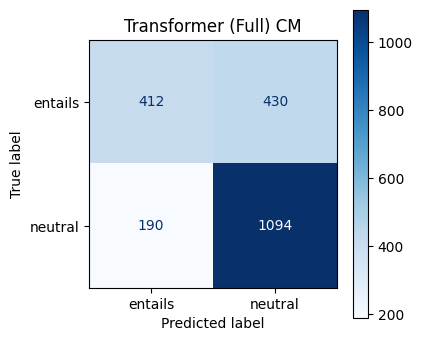

In [ ]:
# Load the best model state for evaluation
model_trans_full = NLI_Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX
).to(DEVICE)
model_trans_full.load_state_dict(torch.load('transformer_full.pt'))
model_trans_full.eval() # Set to evaluation mode

test_dataset = NLIDataset(test_df, vocab_stoi, label_map, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
criterion = nn.CrossEntropyLoss() # Define criterion for evaluation

test_loss_trans_full, test_accuracy_trans_full, test_precision_trans_full, test_recall_trans_full, test_f1_trans_full, true_labels_trans_full, predicted_labels_trans_full = evaluate(model_trans_full, test_loader, criterion)

print(f"\n--- Transformer Performance (Full Attention) ---")
print(f"Loss: {test_loss_trans_full:.3f} | Accuracy: {test_accuracy_trans_full:.5f}%")
print(f"Precision: {test_precision_trans_full} | Recall: {test_recall_trans_full} | F1: {test_f1_trans_full}")

# Confusion Matrix for Transformer
cm_trans_full = confusion_matrix(true_labels_trans_full, predicted_labels_trans_full)
disp_trans_full = ConfusionMatrixDisplay(confusion_matrix=cm_trans_full, display_labels=list(label_map.keys()))
fig, ax = plt.subplots(figsize=(4, 4))
disp_trans_full.plot(cmap='Blues', ax=ax)
plt.title('Transformer (Full) CM')
plt.show()

### LSTM

Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]


--- LSTM Performance ---
Loss: 0.543 | Accuracy: 0.72342%
Precision: [0.70550162 0.73076923] | Recall: [0.51781473 0.85825545] | F1: [0.59726027 0.78939828]


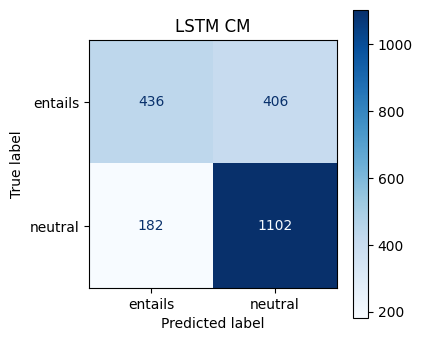

In [ ]:
# Load the best model state for evaluation
lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=PAD_IDX
).to(DEVICE)
lstm_model.load_state_dict(torch.load('lstm_emb_128.pt'))
lstm_model.eval() # Set to evaluation mode

test_dataset = NLIDataset(test_df, vocab_stoi, label_map, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
criterion = nn.CrossEntropyLoss() # Define criterion for evaluation

test_loss_lstm, test_accuracy_lstm, test_precision_lstm, test_recall_lstm, test_f1_lstm, true_labels_lstm, predicted_labels_lstm = evaluate(lstm_model, test_loader, criterion)

print(f"\n--- LSTM Performance ---")
print(f"Loss: {test_loss_lstm:.3f} | Accuracy: {test_accuracy_lstm:.5f}%")
print(f"Precision: {test_precision_lstm} | Recall: {test_recall_lstm} | F1: {test_f1_lstm}")

# Confusion Matrix for LSTM
cm_lstm = confusion_matrix(true_labels_lstm, predicted_labels_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=list(label_map.keys()))
fig, ax = plt.subplots(figsize=(4, 4))
disp_lstm.plot(cmap='Blues', ax=ax)
plt.title('LSTM CM')
plt.show()

### Convolutional Neural Network

Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]


--- CNN Performance ---
Loss: 0.572 | Accuracy: 0.70602%
Precision: [0.7209776  0.70152905] | Recall: [0.42042755 0.89330218] | F1: [0.53113278 0.78588558]


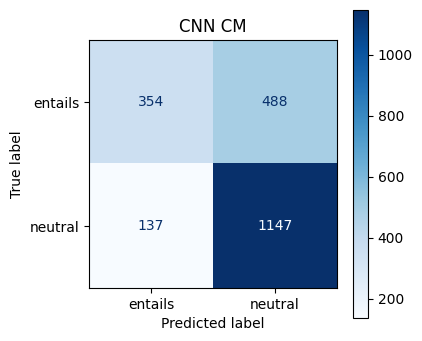

In [ ]:
# Load the best model state for evaluation
cnn_model = CNNClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    n_filters=N_FILTERS,
    filter_sizes=FILTER_SIZES,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
).to(DEVICE)
cnn_model.load_state_dict(torch.load('cnn.pt'))
cnn_model.eval() # Set to evaluation mode

test_dataset = NLIDataset(test_df, vocab_stoi, label_map, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
criterion = nn.CrossEntropyLoss() # Define criterion for evaluation

test_loss_cnn, test_accuracy_cnn, test_precision_cnn, test_recall_cnn, test_f1_cnn, true_labels_cnn, predicted_labels_cnn = evaluate(cnn_model, test_loader, criterion)

print("\n--- CNN Performance ---")
print(f"Loss: {test_loss_cnn:.3f} | Accuracy: {test_accuracy_cnn:.5f}%")
print(f"Precision: {test_precision_cnn} | Recall: {test_recall_cnn} | F1: {test_f1_cnn}")

cm_cnn = confusion_matrix(true_labels_cnn, predicted_labels_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=list(label_map.keys()))
fig, ax = plt.subplots(figsize=(4, 4))
disp_cnn.plot(cmap='Blues', ax=ax)
plt.title('CNN CM')
plt.show()

### Attention Ablation Study

INFO - Running Attention Ablation Study Evaluation.


Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]


--- Attention Ablation Performance: Structured ---
Loss: 0.576 | Accuracy: 0.68815%
Precision: [0.59179487 0.76976542] | Recall: [0.68527316 0.69003115] | F1: [0.63511282 0.72772074]


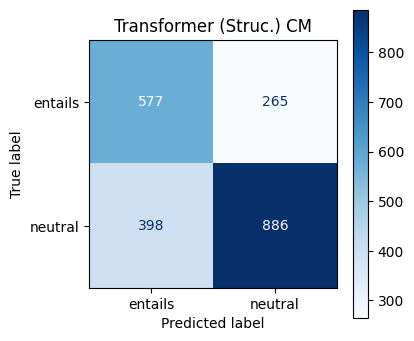

In [ ]:
# Load the best structured model state for evaluation
model_trans_stru = NLI_Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    attention_mode="structured"
).to(DEVICE)
model_trans_stru.load_state_dict(torch.load('transformer_struc.pt'))
model_trans_stru.eval() # Set to evaluation mode

# Evaluate on the test set
logging.info(f"Running Attention Ablation Study Evaluation.")
test_dataset = NLIDataset(test_df, vocab_stoi, label_map, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
criterion = nn.CrossEntropyLoss() # Define criterion for evaluation

test_loss_trans_stru, test_accuracy_trans_stru, test_precision_trans_stru, test_recall_trans_stru, test_f1_trans_stru, true_labels_trans_stru, predicted_labels_trans_stru = evaluate(model_trans_stru, test_loader, criterion)

# Display results for the structured attention model only
print(f"\n--- Attention Ablation Performance: Structured ---")
print(f"Loss: {test_loss_trans_stru:.3f} | Accuracy: {test_accuracy_trans_stru:.5f}%")
print(f"Precision: {test_precision_trans_stru} | Recall: {test_recall_trans_stru} | F1: {test_f1_trans_stru}")

# Confusion Matrix for Structured Attention Ablation Study
cm_trans_stru = confusion_matrix(true_labels_trans_stru, predicted_labels_trans_stru)
disp_trans_stru = ConfusionMatrixDisplay(confusion_matrix=cm_trans_stru, display_labels=list(label_map.keys()))
fig, ax = plt.subplots(figsize=(4, 4))
disp_trans_stru.plot(cmap='Blues', ax=ax)
plt.title('Transformer (Struc.) CM')
plt.show()

### Hyperparameter Ablation Study

INFO - Running Hyperparameter Ablation Study Evaluation.
INFO - Evaluating LSTM with embedding dimension: 32.


Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]

INFO - Evaluating LSTM with embedding dimension: 64.


Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]

INFO - Evaluating LSTM with embedding dimension: 128.


Evaluating:   0%|          | 0/67 [00:00<?, ?it/s]

INFO - Displaying results for LSTM Hyperparameter Ablation.



--- Hyperparameter Ablation Performance: Embedding Dim 32 ---
Loss: 0.637 | Accuracy: 0.68815%
Precision: [0.603708   0.74584323] | Recall: [0.61876485 0.73364486] | F1: [0.6111437  0.73969376]


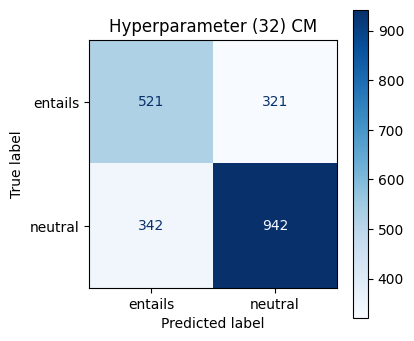


--- Hyperparameter Ablation Performance: Embedding Dim 64 ---
Loss: 0.596 | Accuracy: 0.70696%
Precision: [0.66222222 0.72777395] | Recall: [0.53087886 0.82242991] | F1: [0.58932103 0.77221207]


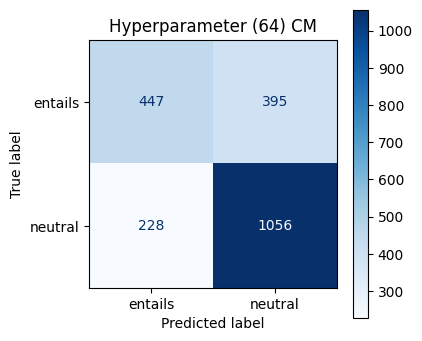


--- Hyperparameter Ablation Performance: Embedding Dim 128 ---
Loss: 0.543 | Accuracy: 0.72342%
Precision: [0.70550162 0.73076923] | Recall: [0.51781473 0.85825545] | F1: [0.59726027 0.78939828]


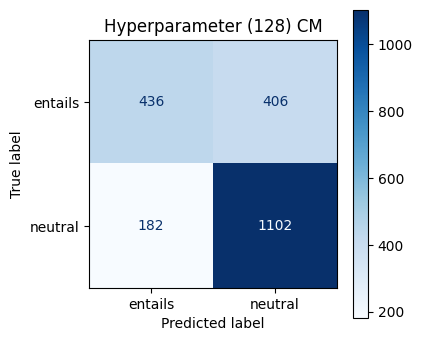

In [ ]:
logging.info("Running Hyperparameter Ablation Study Evaluation.")
results_hyp_abl = {}
embedding_dim_options_to_evaluate = [32, 64, 128]

for emb_dim in embedding_dim_options_to_evaluate:
    logging.info(f"Evaluating LSTM with embedding dimension: {emb_dim}.")

    model_to_evaluate = LSTMClassifier(
        vocab_size=VOCAB_SIZE,
        embed_dim=emb_dim,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        pad_idx=PAD_IDX
    ).to(DEVICE)

    model_filename = f'lstm_emb_{emb_dim}.pt'
    model_to_evaluate.load_state_dict(torch.load(model_filename))
    model_to_evaluate.eval()

    results_hyp_abl[emb_dim] = evaluate(model_to_evaluate, test_loader, criterion)

logging.info("Displaying results for LSTM Hyperparameter Ablation.")
for emb_dim in embedding_dim_options_to_evaluate:
    (test_loss_hyp_abl, test_accuracy_hyp_abl, test_precision_hyp_abl,
     test_recall_hyp_abl, test_f1_hyp_abl, true_labels_hyp_abl,
     predicted_labels_hyp_abl) = results_hyp_abl[emb_dim]

    print(f"\n--- Hyperparameter Ablation Performance: Embedding Dim {emb_dim} ---")
    print(f"Loss: {test_loss_hyp_abl:.3f} | Accuracy: {test_accuracy_hyp_abl:.5f}%")
    print(f"Precision: {test_precision_hyp_abl} | Recall: {test_recall_hyp_abl} | F1: {test_f1_hyp_abl}")

    cm_hyp_abl = confusion_matrix(true_labels_hyp_abl, predicted_labels_hyp_abl)
    disp_hyp_abl = ConfusionMatrixDisplay(confusion_matrix=cm_hyp_abl, display_labels=list(label_map.keys()))
    fig, ax = plt.subplots(figsize=(4, 4))
    disp_hyp_abl.plot(cmap='Blues', ax=ax)
    plt.title(f'Hyperparameter ({emb_dim}) CM')
    plt.show()

### Qualitative Analysis

In [ ]:
def visualize_attention(model, test_loader, vocab_stoi, label_map, device, sample_idx=0):
    # Create an inverse vocabulary to map indices back to words for plotting
    itos = {i: s for s, i in vocab_stoi.items()}

    model.eval()
    with torch.no_grad():
        # Get a single batch of data from the test loader
        batch = next(iter(test_loader))
        text, labels = batch
        text, labels = text.to(device), labels.to(device)

        # Select the specific sample to visualize
        input_ids = text[sample_idx].unsqueeze(0) # Keep batch dimension
        true_label_idx = labels[sample_idx].item()
        true_label = list(label_map.keys())[list(label_map.values()).index(true_label_idx)]

        # Get model predictions and attention weights
        logits, attention_weights = model(input_ids, return_att_weights=True)

        # Get the predicted label for the title
        pred_label_idx = torch.argmax(logits, dim=1).item()
        pred_label = list(label_map.keys())[list(label_map.values()).index(pred_label_idx)]

        # Average the weights across all attention heads for a 2D plot
        avg_attention = attention_weights.squeeze(0).cpu().numpy()

        # Convert the input tensor of token IDs back into a list of word strings
        tokens = [itos[idx.item()] for idx in input_ids.squeeze(0)]

        # Remove padding tokens for a cleaner plot
        try:
            pad_start_index = tokens.index('<pad>')
            tokens = tokens[:pad_start_index]
            avg_attention = avg_attention[:pad_start_index, :pad_start_index]
        except ValueError:
            # No padding found in this sequence
            pass

        # Create the heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(avg_attention, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
        plt.title(f'Attention Heatmap (Sample {sample_idx})\nTrue Label: "{true_label}" | Predicted Label: "{pred_label}"', fontsize=16)
        plt.xlabel('Key (Tokens Being Attended To)', fontsize=12)
        plt.ylabel('Query (Tokens Attending From)', fontsize=12)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.show()

# Instantiate the model for visualization
visualization_model = NLI_Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX
).to(DEVICE)

visualization_model.load_state_dict(torch.load('transformer_full.pt'))

vis_test_dataset = NLIDataset(test_df, vocab_stoi, label_map, MAX_LEN)
vis_test_loader = DataLoader(vis_test_dataset, batch_size=BATCH_SIZE)

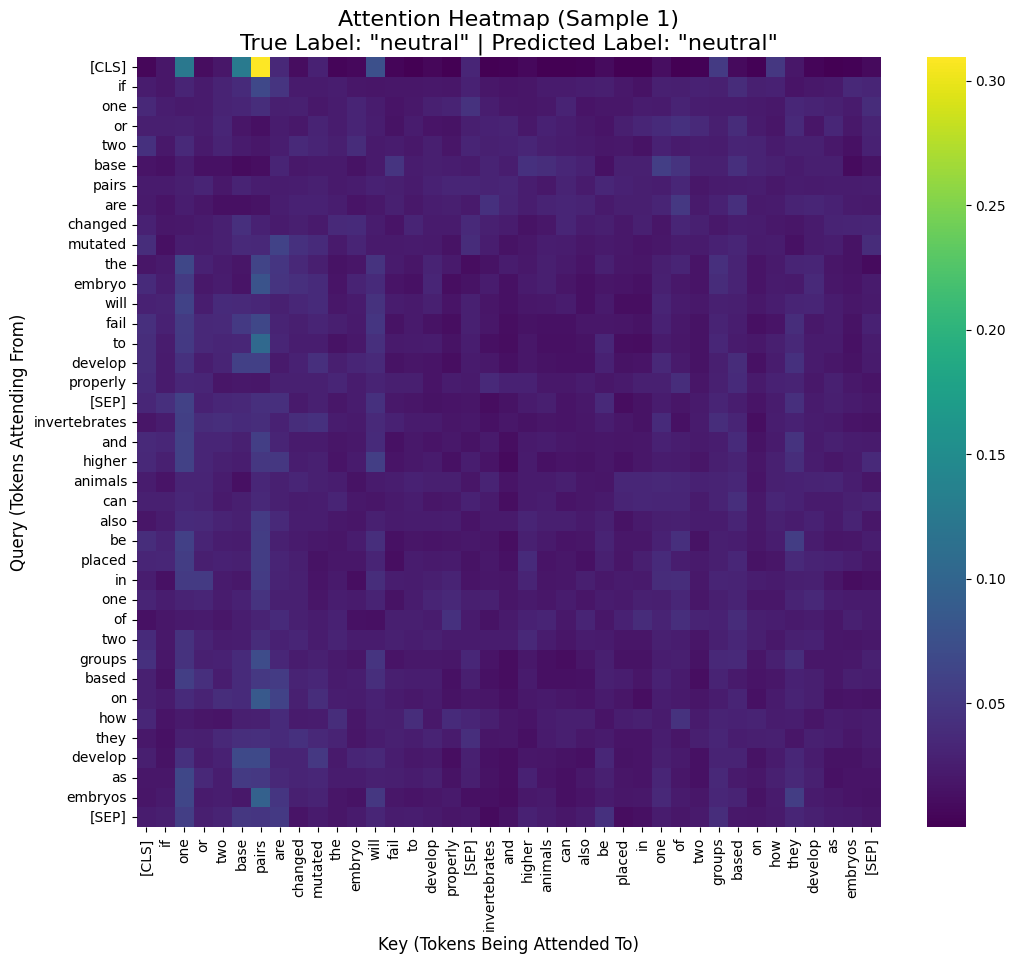

In [ ]:
    visualize_attention(
        model=visualization_model,
        test_loader=vis_test_loader,
        vocab_stoi=vocab_stoi,
        label_map=label_map,
        device=DEVICE,
        sample_idx=1
    )

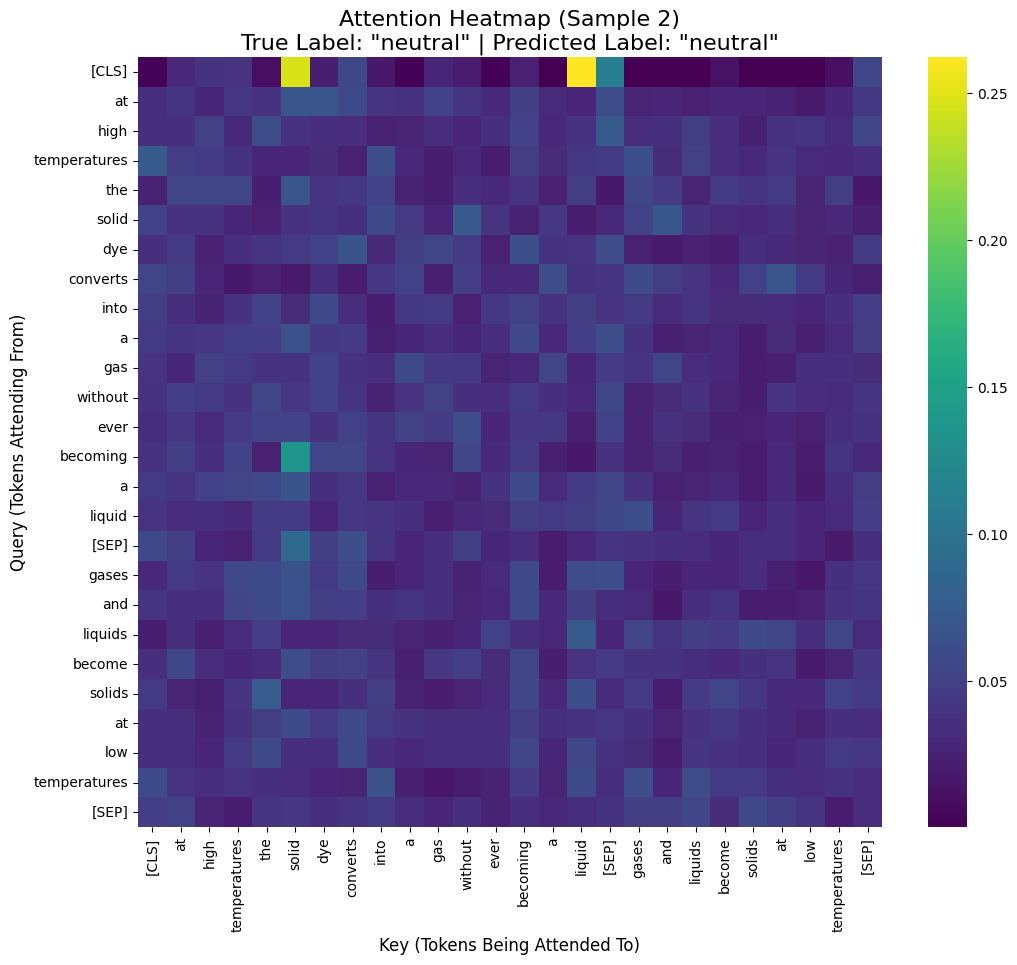

In [ ]:
    visualize_attention(
        model=visualization_model,
        test_loader=vis_test_loader,
        vocab_stoi=vocab_stoi,
        label_map=label_map,
        device=DEVICE,
        sample_idx=2
    )